<a href="https://colab.research.google.com/github/harshs-data/Deep-Learning/blob/main/ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense, Flatten
from keras.models import Sequential

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train.shape

(60000, 28, 28)

0


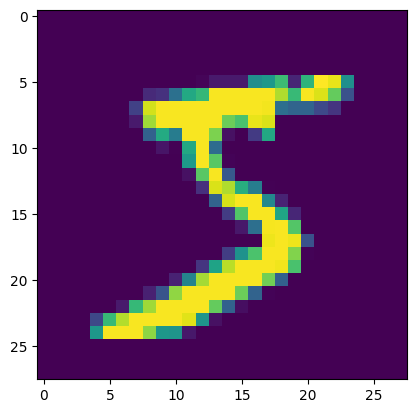

In [28]:
print(y_train[1])
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [5]:
X_train = X_train/255
X_test = X_test/255

In [6]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [7]:
model = Sequential()

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [33]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9958 - loss: 0.0144 - val_accuracy: 0.9755 - val_loss: 0.1004
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9967 - loss: 0.0116 - val_accuracy: 0.9741 - val_loss: 0.1027
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9973 - loss: 0.0100 - val_accuracy: 0.9778 - val_loss: 0.0975
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9977 - loss: 0.0079 - val_accuracy: 0.9778 - val_loss: 0.0996
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9970 - loss: 0.0096 - val_accuracy: 0.9753 - val_loss: 0.1169
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9986 - loss: 0.0054 - val_accuracy: 0.9775 - val_loss: 0.1036
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9974 - loss: 0.0078 - val_accuracy: 0.9771 - val_loss: 0.1076
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9978 - loss: 0.0072 - 

In [34]:
y_prob=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [35]:
import numpy as np
y_pred = np.argmax(y_prob, axis=1)

In [36]:
y_pred

array([7, 2, 1, ..., 4, 5, 6])

In [44]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.9783

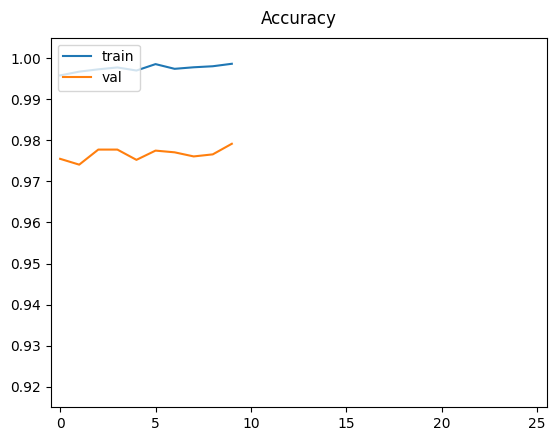

In [54]:
import matplotlib.pyplot as plt

# 1. Force the clean, standard classic style (no gridlines, plain white background)
plt.style.use('default')
plt.figure(figsize=(6.4, 4.8)) # Standard default Matplotlib aspect ratio

# 2. Extract metrics safely
train_acc = history.history.get('accuracy', history.history.get('acc'))
val_acc = history.history.get('val_accuracy', history.history.get('val_acc'))

# 3. Plot lines with the thin, standard default widths
plt.plot(train_acc, label='train', color='#1f77b4', linewidth=1.5)
plt.plot(val_acc, label='val', color='#ff7f0e', linewidth=1.5)

# 4. Replicate the precise Title and Legend formatting from your second image
plt.title('Accuracy', fontsize=12, pad=10)
plt.legend(loc='upper left', frameon=True)

# 5. Lock in the exact axes ranges visible in your first image
plt.xlim(-0.5, 25.5)   # Captures the full 25 epochs comfortably
plt.ylim(0.915, 1.005)  # Keeps the y-axis scaling identical to image 1

# 6. Render cleanly without text artifacts
plt.show()


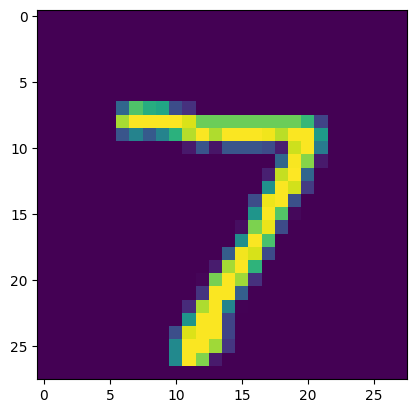

In [58]:
plt.imshow(X_test[0])

In [62]:
import numpy as np
model.predict(np.expand_dims(X_test[0], axis=0)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


array([7])